In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [18]:
tickers = ['GGAL', 'YPF', 'MELI', 'SPY']

In [19]:
periodo = '3y'

In [20]:
datos = yf.download(tickers, period=periodo, auto_adjust=True)

[*********************100%***********************]  4 of 4 completed


In [21]:
precios = datos['Close']

In [22]:
print(precios.dtypes)

Ticker
GGAL    float64
MELI    float64
SPY     float64
YPF     float64
dtype: object


In [23]:
print(f"\nDesde: {precios.index.min().date()}  Hasta: {precios.index.max().date()}")


Desde: 2023-06-20  Hasta: 2026-06-18


In [24]:
print("\nValores nulos por acción:")
print(precios.isnull().sum())


Valores nulos por acción:
Ticker
GGAL    0
MELI    0
SPY     0
YPF     0
dtype: int64


In [25]:
precios = precios.ffill().dropna()

In [26]:
print("\nEstadísticas descriptivas:")
print(precios.describe())


Estadísticas descriptivas:
Ticker        GGAL         MELI         SPY         YPF
count   753.000000   753.000000  753.000000  753.000000
mean     37.182333  1844.037253  564.690512   28.042922
std      16.472965   366.172034   92.965619   10.734119
min       9.745108  1087.150024  397.044067    9.930000
25%      21.814255  1595.300049  492.978455   18.670000
50%      41.537777  1828.729980  565.091309   27.160000
75%      51.354908  2095.270020  647.654236   36.279999
max      68.521210  2613.629883  757.618225   56.349998


In [33]:
precios.to_csv('../data/precios_historicos.csv')
print("\nDatos guardados en data/precios_historicos.csv")


Datos guardados en data/precios_historicos.csv


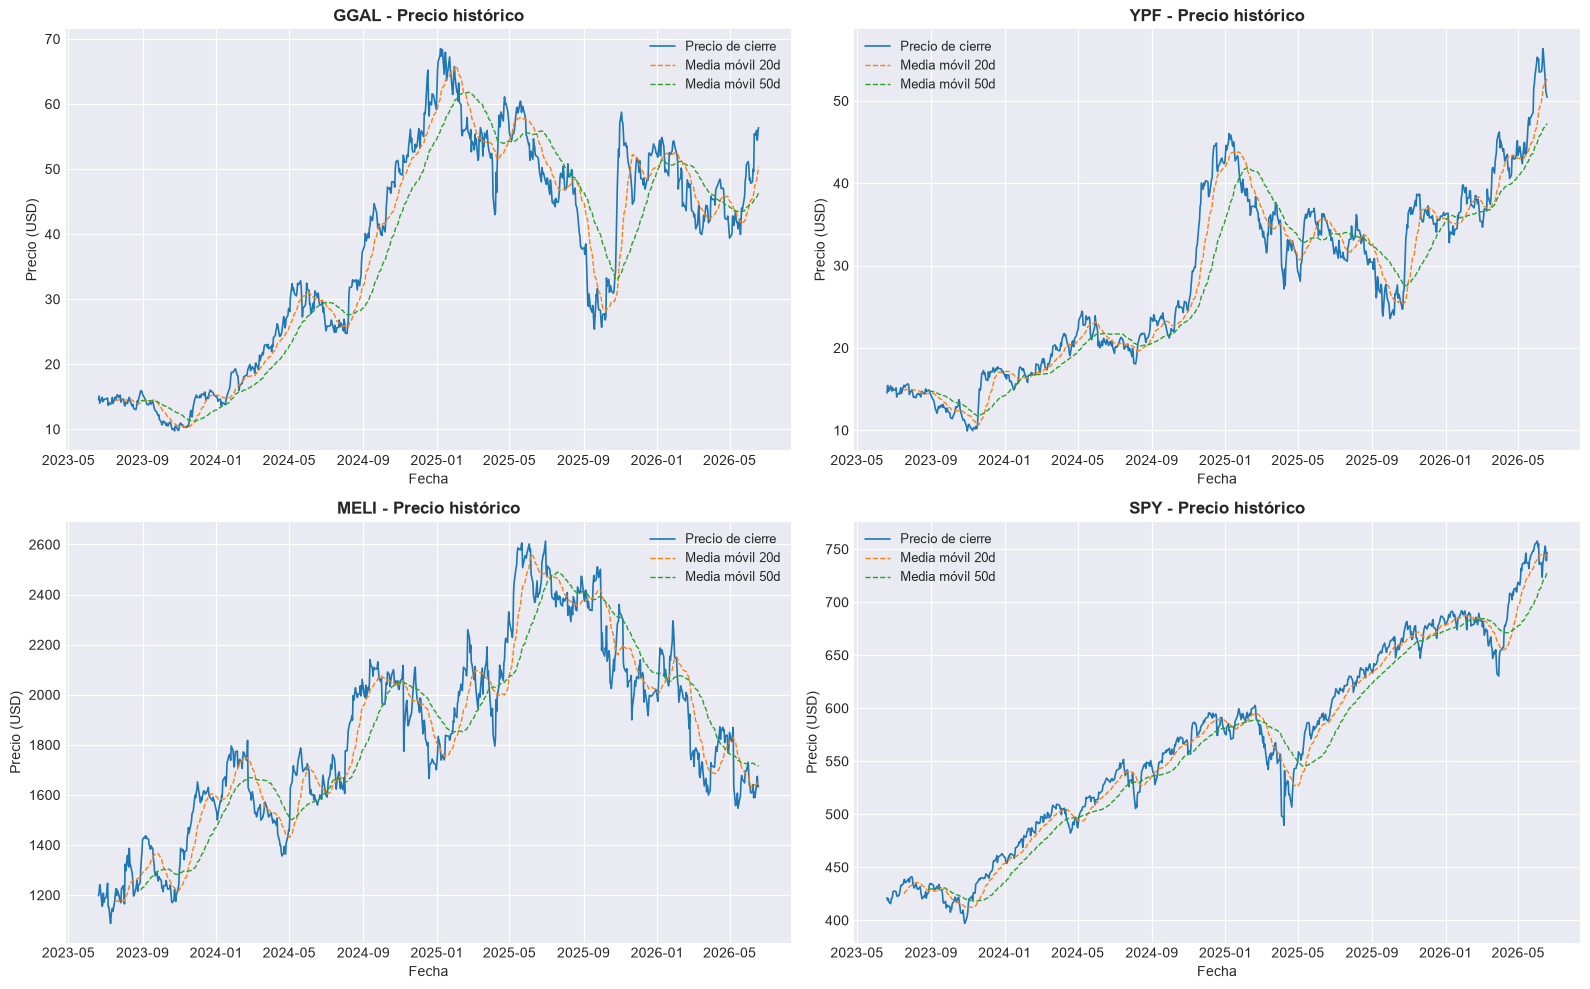

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    precio_ticker = precios[ticker]

    # Media móvil de 20 y 50 días
    media_20 = precio_ticker.rolling(window=20).mean()
    media_50 = precio_ticker.rolling(window=50).mean()

    axes[i].plot(precio_ticker.index, precio_ticker, label='Precio de cierre', linewidth=1.2)
    axes[i].plot(media_20.index, media_20, label='Media móvil 20d', linestyle='--', linewidth=1)
    axes[i].plot(media_50.index, media_50, label='Media móvil 50d', linestyle='--', linewidth=1)

    axes[i].set_title(f'{ticker} - Precio histórico', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Fecha')
    axes[i].set_ylabel('Precio (USD)')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/precios_medias_moviles.png', dpi=150)
plt.show()


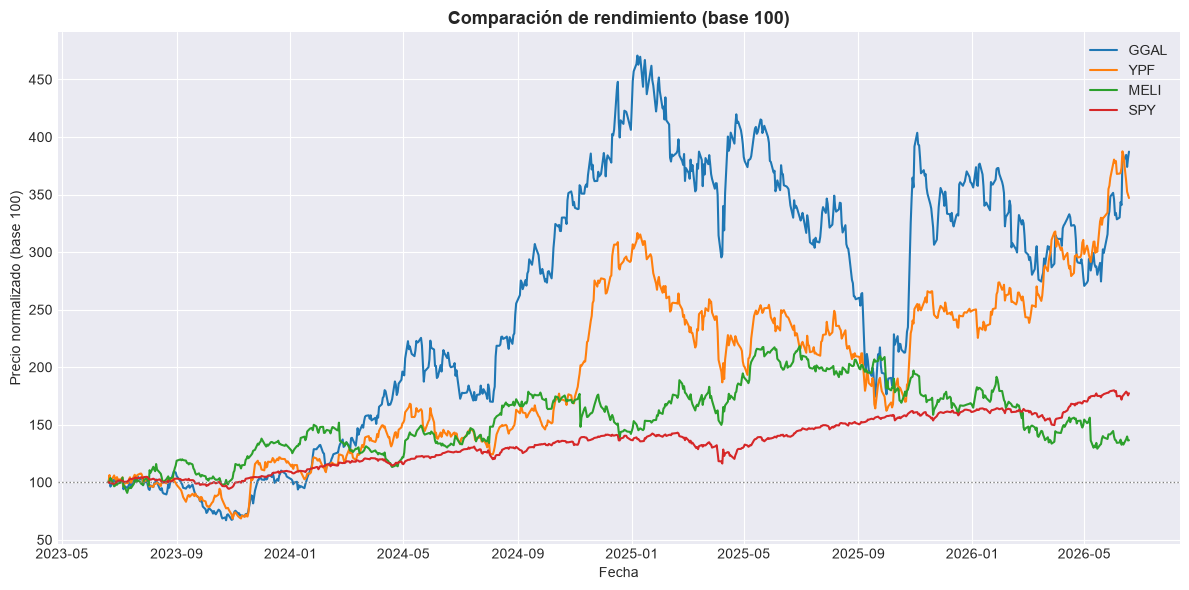


✅ Notebook 1 completo. Datos listos para el análisis de retornos (Notebook 2).


In [35]:
precios_normalizados = (precios / precios.iloc[0]) * 100

plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(precios_normalizados.index, precios_normalizados[ticker], label=ticker, linewidth=1.5)

plt.title('Comparación de rendimiento (base 100)', fontsize=13, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Precio normalizado (base 100)')
plt.legend()
plt.axhline(y=100, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('../data/precios_normalizados.png', dpi=150)
plt.show()

print("\n✅ Notebook 1 completo. Datos listos para el análisis de retornos (Notebook 2).")

## Observaciones

- En el período analizado (últimos 3 años), GGAL mostró la tendencia de
  precio más marcada al alza entre los activos del portafolio, seguida de
  cerca por YPF, ambas reflejando la fuerte revalorización de activos
  argentinos en dólares durante este período.

- Al normalizar los precios a base 100, GGAL y YPF se despegan claramente
  de MELI y SPY, anticipando lo que luego se confirma en el análisis de
  retornos: ambos activos argentinos concentraron el mayor crecimiento
  acumulado del portafolio.

- SPY, al ser un ETF diversificado sobre el S&P 500, muestra una trayectoria
  visualmente más estable y con menos oscilaciones bruscas frente a las
  acciones individuales, consistente con su menor volatilidad relativa.